Train Mean Absolute Error: 115.2917018289656
Test Mean Absolute Error: 204.476915756553
Train R-squared Score: 0.9914888316286551
Test R-squared Score: 0.9787826789729837


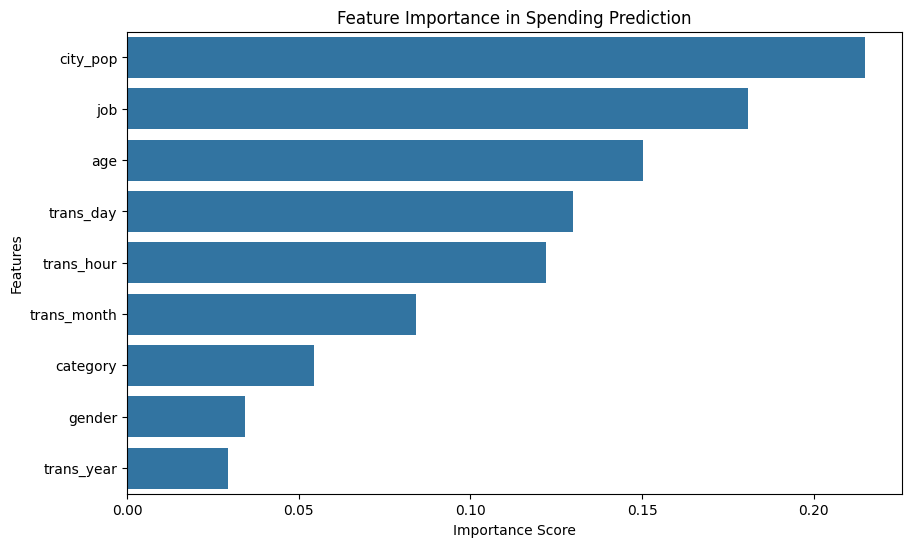

['label_encoders.pkl']

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load dataset
file_path = "/content/Augmented_IndiaTransactMultiFacet2024.csv"  # Change this to your actual file path
df = pd.read_csv(file_path, encoding="utf-8", low_memory=False)

# Drop unnecessary columns
drop_cols = ['trans_id', 'cc_num', 'merchant', 'first', 'last', 'street', 'city',
             'state', 'lat', 'long', 'merch_lat', 'merch_long', 'customer_id', 'is_fraud']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

# Convert transaction date to useful features
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], errors='coerce')
df['trans_year'] = df['trans_date_trans_time'].dt.year
df['trans_month'] = df['trans_date_trans_time'].dt.month
df['trans_day'] = df['trans_date_trans_time'].dt.day
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df.drop(columns=['trans_date_trans_time'], inplace=True)  # Drop original date column

# Convert DOB to Age
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')  # Handle parsing errors
df['age'] = datetime.now().year - df['dob'].dt.year
df.drop(columns=['dob'], inplace=True)

# Handle missing values
df.dropna(subset=['amt'], inplace=True)  # Remove rows where 'amt' is NaN
df.fillna(df.median(numeric_only=True), inplace=True)  # Impute missing values in other columns

# Encode categorical features
label_encoders = {}
categorical_cols = ['category', 'gender', 'job']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Define features and target
X = df.drop(columns=['amt'])  # Predicting spending behavior (amt)
y = np.log1p(df['amt'])  # Apply log transformation to target variable

# Scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Spending Behavior Analysis Model
spending_model = RandomForestRegressor(
    n_estimators=150, max_depth=25, min_samples_split=4, min_samples_leaf=2, random_state=42
)
spending_model.fit(X_train, y_train)
y_train_preds = spending_model.predict(X_train)
y_test_preds = spending_model.predict(X_test)

# Transform predictions back to original scale
y_train_preds = np.expm1(y_train_preds)
y_test_preds = np.expm1(y_test_preds)
y_train = np.expm1(y_train)
y_test = np.expm1(y_test)

# Evaluate the model
train_mae = mean_absolute_error(y_train, y_train_preds)
test_mae = mean_absolute_error(y_test, y_test_preds)
train_r2 = r2_score(y_train, y_train_preds)
test_r2 = r2_score(y_test, y_test_preds)

print("Train Mean Absolute Error:", train_mae)
print("Test Mean Absolute Error:", test_mae)
print("Train R-squared Score:", train_r2)
print("Test R-squared Score:", test_r2)

# Feature Importance
feature_importance = pd.Series(spending_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Feature Importance in Spending Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

# Save Model and Encoders
joblib.dump(spending_model, 'spending_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')